In [20]:
import serial
from ReadWrite import ReadWrite
import pandas as pd
from matplotlib import pyplot as plt
from Network import RKMNetwork
from func_timeout import func_timeout, FunctionTimedOut
import time
import ast
import numpy as np
import scipy
print(scipy.__version__)
# from scipy.interpolate import make_smoothing_spline

# from scipy.interpolate import UnivariateSpline as make_smoothing_spline

import os
lam = 20
import random

1.5.4


In [131]:
port = "/dev/ttyACM1" # Replace with your serial port
baudrate = 250000
ser = serial.Serial(port, baudrate)
ser.is_open

True


  name  isWeight Anode Bnode
0  BV0         0    A0    V0
1  BH0         0    A0    H0
2  W00         1    V0    H0


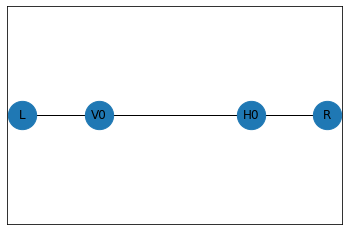

In [132]:
numV = 1
numH = 1

net = RKMNetwork(numV,numH)

net.draw_network()

print(net.edge)
# print(net.node)

In [133]:
def cleanup_mes(thisdict): 
    ki = thisdict['ki']
    DA = thisdict['DA']
    DB = thisdict['DB']
    RA = thisdict['RA']
    RB = thisdict['RB']
    
    if not (net.run_nodechecks(DA, DB) and net.run_nodechecks(RA, RB)):
        print("failed nodecheck")
        return None
    
    edges = dict(zip(net.edge.name, ki))
    
    Dnodes = dict(zip(net.edge.Anode, DA))
    Dnodes.update(dict(zip(net.edge.Bnode, DB)))
    
    Rnodes = dict(zip(net.edge.Anode, RA))
    Rnodes.update(dict(zip(net.edge.Bnode, RB)))

    
    newdict = {}
    newdict.update(edges)
    
    for key in Dnodes:
        newdict['D' + key] = Dnodes[key]
    
    for key in Rnodes:
        newdict['R' + key] = Rnodes[key]
        
    return newdict

In [134]:
aConvert = (3.3)/(4095.)
def cleanup_dict(thisdict): 
    aConvert = (3.3)/(4095.)
    ki = thisdict['ki']
    DA = thisdict['DA']
    DB = thisdict['DB']
    RA = thisdict['RA']
    RB = thisdict['RB']
    
    nmestimes = 5. #thisdict['nmestimes']
    aConvert = aConvert*1/nmestimes
    
    if not (net.run_nodechecks(DA, DB) and net.run_nodechecks(RA, RB)):
        print("failed nodecheck")
        return None
    
    edges = dict(zip(net.edge.name, ki))
    
    Dnodes = dict(zip(net.edge.Anode, DA))
    Dnodes.update(dict(zip(net.edge.Bnode, DB)))
    
    Rnodes = dict(zip(net.edge.Anode, RA))
    Rnodes.update(dict(zip(net.edge.Bnode, RB)))

    
    newdict = {'epoch': thisdict['epoch'],  'trainingstep': thisdict['epoch'], 
               'Vtest': thisdict['Vtest'], 'Vrecon': thisdict['Vrecon'],
               'Vtest_det': thisdict['Vtest_det'], 'Vrecon_det': thisdict['Vrecon_det']}
    newdict.update(edges)
    
    for key in Dnodes:
        newdict['D' + key] = Dnodes[key]
    
    for key in Rnodes:
        newdict['R' + key] = Rnodes[key]

    try:
        azero = np.array(thisdict['analogZero'], dtype='float')*aConvert
        newdict['analogZero'] = azero
        
        analogV = thisdict['analogV']
        analogH = thisdict['analogH']
        for i, val in enumerate(analogV):
            newdict['aV' + str(i)] = val*aConvert
        
        for i, val in enumerate(analogH):
            newdict['aH' + str(i)] = val*aConvert
    except Exception as e: 
        print('Epoch', newdict['epoch'])
        print(e)
        
    return newdict

In [136]:
RW = ReadWrite(ser)

In [137]:
# print info about the experiment

RW.clear_output()
RW.send_message("ps;")
time.sleep(1)
experiment_data = RW.measure()

ebAddress = experiment_data['ebAddress']

sending edge type and index
BV, 0
BH, 1
W, 2
ebAddress, [1]
Veidx, [0, 2]
isAB, [1, 0]
whichV, [0, 0]
numtrain, 1
dataset, [0]
testidx, [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
finished


In [145]:
# setup random seeds and perform an initial measurement

seeds = np.random.randint(0, 100, len(ebAddress))

while len(seeds) > len(set(seeds)):
    for i in range(len(seeds)):
        seeds[i] = random.randint(0, 100)

for i in range(len(ebAddress)):
    RW.send_recieve("seed;{};{};".format(ebAddress[i], seeds[i]))
    time.sleep(1)

    
RW.send_recieve("rd;")
RW.send_recieve("rr;")
time.sleep(1)
RW.send_message("mes;")
mes = RW.measure()
cleanup_mes(mes)

seed, 54
finished
recordD triggered
finished
recordR triggered
finished
ki, [5, 0, -10]
DA, [1, 1, 0]
DB, [0, 1, 1]
RA, [1, 1, 0]
RB, [0, 1, 1]
finished


{'BV0': 5,
 'BH0': 0,
 'W00': -10,
 'DA0': 1,
 'DV0': 0,
 'DH0': 1,
 'RA0': 1,
 'RV0': 0,
 'RH0': 1}

In [146]:
# set hyperparameters for training

# temp = 500 #mV
# for now, replace this with a digival
digitemp = 50
L2 = 7
L2maxexp = 4 
# we can replace this with singular value of lambda

epochs= 100
alpha = 1 # learning rate in units of digipot clicks
kwvar = 30 #initialization of weights
kbvar = 5 #initialization of bias
detinf = 1 #are we getting deterministic inference measurements (1) or not (0)
measureEvery = 10 #how many epochs to skip between measurements


ensemblename = 'test_1x1_digitemp_{}_L2_{}_L2max_{}_05052026'.format(digitemp, L2, L2maxexp) #save folder

if not os.path.exists('data/trainings/{}/'.format(ensemblename)):
        os.mkdir('data/trainings/{}/'.format(ensemblename))

RW.send_recieve("alpha;{};".format(alpha))
time.sleep(1)
RW.send_recieve("kwvar;{};".format(kwvar))
time.sleep(1)
RW.send_recieve("kbvar;{};".format(kbvar))
time.sleep(1)
RW.send_recieve("L2;{};".format(L2))
time.sleep(1)
RW.send_recieve("L2max;{};".format(str(int(L2maxexp))))
time.sleep(1)
RW.send_recieve("detinf;{};".format(detinf))
time.sleep(1)
RW.send_recieve("measureEvery;{};".format(measureEvery))
time.sleep(1)

RW.send_recieve("setvtemp;{};".format(digitemp))
time.sleep(1)
RW.send_recieve("sethtemp;{};".format(digitemp))
time.sleep(1)

alpha, 1
finished
kwvar, 30
finished
kbvar, 5
finished
L2, 7
finished
L2max, 4
finished
detInf, 1
finished
measureEvery, 10
finished
set Vtemp, 50
finished
set Htemp, 50
finished


In [147]:
# check edge initialization works according to hyperparams

RW.send_recieve("norm;")
time.sleep(1)
RW.clear_output()
RW.send_message("mes;")
mes = RW.measure()
cleanup_mes(mes)

normed
finished
ki, [5, 0, -12]
DA, [1, 1, 0]
DB, [0, 1, 1]
RA, [1, 1, 0]
RB, [0, 1, 1]
finished


{'BV0': 5,
 'BH0': 0,
 'W00': -12,
 'DA0': 1,
 'DV0': 0,
 'DH0': 1,
 'RA0': 1,
 'RV0': 0,
 'RH0': 1}

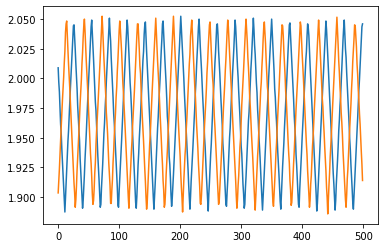

In [148]:
# check temperature signals

RW.clear_output()
time.sleep(1)
RW.send_message("ames;0;")
time.sleep(1)
out = RW.measure(suppress=True)

a0 = float(out['analogZero'])/int(out['nmestimes'])*aConvert

time.sleep(1)
RW.send_message("sampletemp;500;10;{};".format(0))
out = RW.measure(suppress=True)

tempSig = [x*aConvert for x in out['analogTemp']]

plt.plot(tempSig)

RW.send_message("sampletemp;500;10;{};".format(1))
out = RW.measure(suppress=True)

tempSig = [x*aConvert for x in out['analogTemp']]

plt.plot(tempSig)

In [149]:
# train

RW.clear_output()
time.sleep(1)

# set initial values
RW.send_recieve("fb;0;", suppress=True)
time.sleep(1)
RW.send_recieve("useprev;0;", suppress=True)
time.sleep(1)
RW.send_recieve("clamp;0;", suppress=True)
time.sleep(1)
RW.send_recieve("reset;", suppress=True)
time.sleep(1)
RW.send_recieve("norm;", suppress=True)
RW.clear_output()
time.sleep(1)
RW.send_message("mes;")
eki = RW.measure()['ki']

first = dict(zip(net.edge.name, eki))
first['epoch'] = -1
first['trainingstep'] = -1


RW.clear_output()
time.sleep(1)
RW.send_message("train;{};".format(epochs))
listodicts = RW.train_measure(timeoutval=1e4)


listodicts[0].update(first)
try:
    del listodicts[0]['finalizereconstruct']
    del listodicts[0]['testidx']
except:
    print(listodicts[0].keys())

for i in range(1, len(listodicts)):
    listodicts[i] = cleanup_dict(listodicts[i])

df = pd.DataFrame(listodicts)
# # hyperparams
df['L2'] = float(L2)/10**L2maxexp
df['alpha'] = alpha
df['kwvar'] = kwvar
df['kbvar'] = kbvar
df['digitemp'] = digitemp

df.epoch = pd.to_numeric(df.epoch)
df.trainingstep = pd.to_numeric(df.trainingstep)

MSEs = []
MSEs_det = []
for epoch in df.epoch:
    row = df[df.epoch == epoch].iloc[0]


    Vtest = np.array(row.Vtest).T
    Vrecon = np.array(row.Vrecon).T
    MSE = np.mean(np.linalg.norm(Vtest-Vrecon, axis=0))
    MSEs.append(MSE)
    
    try:
        Vtest_det = np.array(row.Vtest_det).T
        Vrecon_det = np.array(row.Vrecon_det).T
        MSEdet = np.mean(np.linalg.norm(Vtest_det-Vrecon_det, axis=0))
        MSEs_det.append(MSEdet)
    except:
        pass


MSEs = np.array(MSEs)
MSEs_det = np.array(MSEs_det)
df['MSE'] = MSEs

if len(MSEs_det) > 0:
    df['MSE_det'] = MSEs_det
print('Done with training')
df

ki, [5, 0, -13]
DA, [1, 1, 0]
DB, [0, 1, 1]
RA, [1, 1, 0]
RB, [0, 1, 1]
finished
Done with training


,Vtest_det,Vrecon_det,Vtest,Vrecon,BV0,BH0,W00,epoch,trainingstep,DA0,...,analogZero,aV0,aH0,L2,alpha,kwvar,kbvar,digitemp,MSE,MSE_det
0,"[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[1], [1], [1], [1], [1], [1], [1], [1], [1], ...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[1], [0], [0], [0], [0], [1], [1], [1], [0], ...",5,0,-13,-1,-1,NaN,...,NaN,NaN,NaN,0.0007,1,30,5,50,0.55,1.0
1,"[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[1], [1], [1], [1], [1], [1], [1], [1], [1], ...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[0], [1], [1], [1], [0], [0], [0], [1], [1], ...",2,-1,-12,9,9,1.0,...,1.971619,1.977744,1.968234,0.0007,1,30,5,50,0.55,1.0
2,"[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[1], [1], [1], [1], [1], [1], [1], [1], [1], ...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[0], [1], [1], [0], [0], [0], [1], [1], [1], ...",-1,-4,-12,19,19,1.0,...,1.971458,1.946476,1.961465,0.0007,1,30,5,50,0.35,1.0
3,"[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[1], [0], [0], [0], [1], [1], [1], [0], [0], ...",-6,-4,-12,29,29,1.0,...,1.970007,1.964205,1.930520,0.0007,1,30,5,50,0.50,0.0
4,"[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[1], [0], [0], [0], [0], [1], [1], [0], [0], ...",-8,-6,-12,39,39,1.0,...,1.970652,1.960337,1.927619,0.0007,1,30,5,50,0.45,0.0
5,"[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[0], [1], [0], [0], [1], [0], [0], [0], [0], ...",-11,-7,-12,49,49,1.0,...,1.970491,1.926330,1.953568,0.0007,1,30,5,50,0.35,0.0
6,"[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[1], [0], [0], [0], [1], [1], [1], [0], [0], ...",-14,-7,-12,59,59,1.0,...,1.969685,1.919722,1.953729,0.0007,1,30,5,50,0.35,0.0
7,"[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[0], [0], [1], [1], [1], [0], [0], [0], [1], ...",-16,-8,-12,69,69,1.0,...,1.969524,1.940029,1.952601,0.0007,1,30,5,50,0.40,0.0
8,"[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[0], [0], [0], [1], [0], [0], [0], [0], [0], ...",-18,-6,-12,79,79,1.0,...,1.970974,1.910535,1.957114,0.0007,1,30,5,50,0.20,0.0
9,"[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[0], [0], [0], [0], [0], [0], [1], [1], [0], ...",-20,-4,-12,89,89,1.0,...,1.969846,1.930037,1.958886,0.0007,1,30,5,50,0.20,0.0


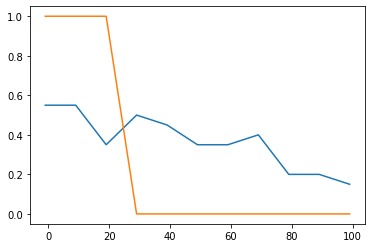

In [150]:
plt.plot(df.epoch, df.MSE)
plt.plot(df.epoch, df.MSE_det)

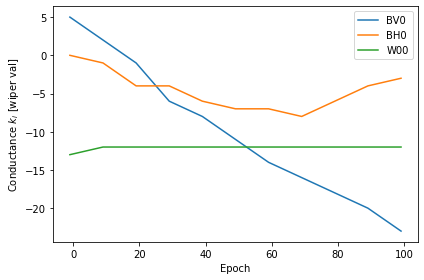

In [151]:
fig, ax = plt.subplots()
for c in df.columns:
    if c[0] == "B" or c[0] == "W":
        ax.plot(df.trainingstep, df[c], label = c)
ax.legend()

ax.set_xlabel("Epoch")
ax.set_ylabel('Conductance $k_i$ [wiper val]')
fig.tight_layout()

At training temp


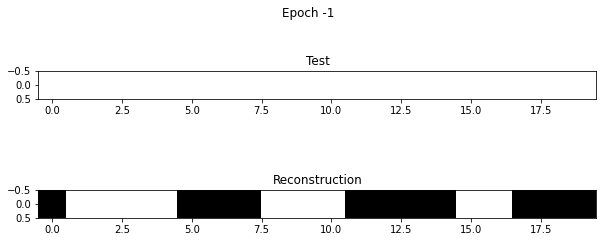

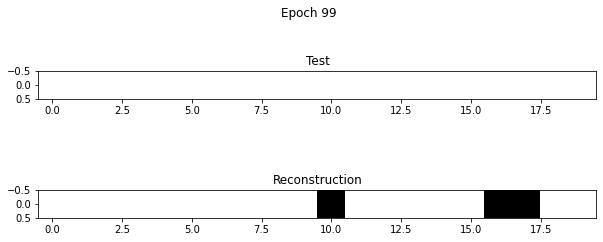

At T=0


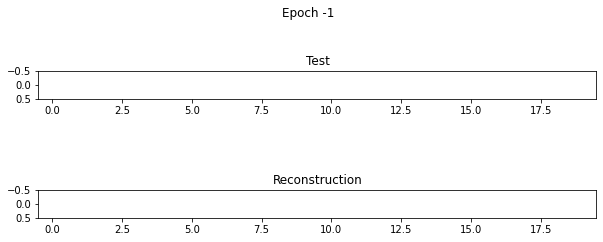

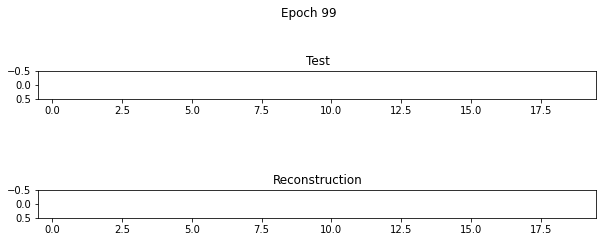

In [152]:
show = [np.min(df.epoch),  np.max(df.epoch)]

print("At training temp")
for epoch in show:
    row = df[df.epoch == epoch].iloc[0]
#     print(row)

    Vtest = np.array(row.Vtest).T
    Vrecon = np.array(row.Vrecon).T
#     print(Vtest)
#     MSE = np.mean(np.linalg.norm(Vtest-Vrecon, axis=0))
#     print(MSE)

    fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,4))
    fig.suptitle("Epoch {}".format(epoch))
    ax1.imshow(Vtest, cmap='binary')
    ax1.set_title('Test')
#     plt.show()
    ax2.imshow(Vrecon, cmap='binary')
    ax2.set_title("Reconstruction")
#     fig.savefig('figures/')
    plt.show()
    # Vrecons
    
try:    
    print("At T=0")
    for epoch in show:
        row = df[df.epoch == epoch].iloc[0]
    #     print(row)

        Vtest = np.array(row.Vtest_det).T
        Vrecon = np.array(row.Vrecon_det).T
    #     print(Vtest)
    #     MSE = np.mean(np.linalg.norm(Vtest-Vrecon, axis=0))
    #     print(MSE)

        fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,4))
        fig.suptitle("Epoch {}".format(epoch))
        ax1.imshow(Vtest, cmap='binary')
        ax1.set_title('Test')
    #     plt.show()
        ax2.imshow(Vrecon, cmap='binary')
        ax2.set_title("Reconstruction")
    #     fig.savefig('figures/')
        plt.show()
        # Vrecons
except:
    pass

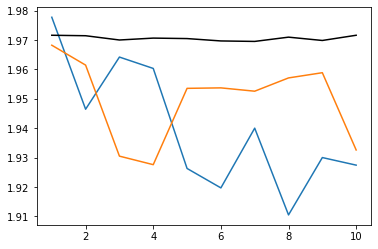

In [153]:
plt.plot(df.aV0)
plt.plot(df.aH0)
plt.plot(df.analogZero, color='k')

In [135]:
# ser.close()